In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mahmoudabdelrazekk/data-star/Star_Dataset.csv


In [33]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import os

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
df=pd.read_csv("/kaggle/input/datasets/mahmoudabdelrazekk/data-star/Star_Dataset.csv")
columns_list = df.columns.tolist()
print(columns_list)

['Time (s)', 'Pressure (MPa)', 'Thrust (N)', 'Length', 'Diameter', 'Number_Of_Points', 'Point_Length', 'Point_Base_Width', 'Throat_Diameter', 'Exit_Diameter', 'Core_Diameter', 'Total Impulse (Ns)', 'ISP (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)', 'Burn Time (s)', 'Avg Thrust (N)', 'Model_ID', 'Grain_Type']


In [34]:
def process_star_data(file_path, num_points=100):
    """
    نفس منطق Bates process_data_final بس:
      - 7 inputs بدل 5  (أضفنا Number_Of_Points, Point_Length, Point_Base_Width)
      - بنشيل Core_Diameter (ثابت = 2.15، zero variance)
      - بنعمل round للـ floats عشان نتخلص من floating point noise
      - Scalars نفسهم: ISP, Total Impulse, Burn Time, Max Thrust
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'File not found: {file_path}')

    print('Loading data...')
    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True)
    df.columns = df.columns.str.strip()

    # Fix floating point noise في الـ nozzle dimensions
    df['Throat_Diameter'] = df['Throat_Diameter'].round(2)
    df['Exit_Diameter']   = df['Exit_Diameter'].round(2)

    df['Model_ID'] = pd.to_numeric(df['Model_ID'], errors='coerce')
    ids = df['Model_ID'].dropna().unique()
    print(f'Total simulations found: {len(ids)}')

    # الـ 7 input features (بدون Core_Diameter)
    INPUT_COLS = [
        'Length',
        'Diameter',
        'Number_Of_Points',
        'Point_Length',
        'Point_Base_Width',
        'Throat_Diameter',
        'Exit_Diameter'
    ]

    X, y_thrust, y_pressure, y_scalars = [], [], [], []

    for uid in ids:
        try:
            case = df[df['Model_ID'] == uid].sort_values('Time (s)')
            inputs = case[INPUT_COLS].iloc[0].values
            t      = case['Time (s)'].values

            # Skip invalid cases
            if len(t) < 2 or t[-1] <= 0 or np.any(inputs <= 0):
                continue

            thrust   = case['Thrust (N)'].fillna(0).values
            pressure = case['Pressure (MPa)'].fillna(0).values

            # Savitzky-Golay smoothing (نفس Bates)
            if len(thrust) > 7:
                thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
                pressure = savgol_filter(pressure, window_length=7, polyorder=3)

            # Interpolate على 100 نقطة موحدة (نفس Bates)
            x_new = np.linspace(t[0], t[-1], num_points)
            X.append(inputs)
            y_thrust.append(interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new))
            y_pressure.append(interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new))

            # Scalars: ISP, Total Impulse, Burn Time, Max Thrust  (نفس Bates)
            y_scalars.append([
                case['ISP (s)'].iloc[0],
                case['Total Impulse (Ns)'].iloc[0],
                t[-1],
                np.max(thrust)
            ])

        except Exception as e:
            continue

    X        = np.array(X, dtype=float)
    y_thrust  = np.array(y_thrust,  dtype=float)
    y_pressure = np.array(y_pressure, dtype=float)
    y_scalars  = np.array(y_scalars,  dtype=float)
    print(f'Processed successfully: {len(X)} cases')
    print(f'Input shape:  {X.shape}       → (n_samples, 7)')
    print(f'Thrust shape: {y_thrust.shape}  → (n_samples, 100)')
    print(f'Pressure shape: {y_pressure.shape}')
    print(f'Scalars shape:  {y_scalars.shape}  → (n_samples, 4)')
    return X, y_thrust, y_pressure, y_scalars


# ── تغيير المسار حسب بيئتك ──────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/mahmoudabdelrazekk/data-star/Star_Dataset.csv'   # Kaggle
# DATA_PATH = 'Star_Dataset.csv'                            # Local / Colab
# ────────────────────────────────────────────────────────────────────

X, yt, yp, ys = process_star_data(DATA_PATH)

Loading data...
Total simulations found: 4202
Processed successfully: 4202 cases
Input shape:  (4202, 7)       → (n_samples, 7)
Thrust shape: (4202, 100)  → (n_samples, 100)
Pressure shape: (4202, 100)
Scalars shape:  (4202, 4)  → (n_samples, 4)


In [35]:
# ── Train / Test Split + Scaling ─────────────────────────────────────
X_train, X_test, yt_train, yt_test, yp_train, yp_test, ys_train, ys_test = \
    train_test_split(X, yt, yp, ys, test_size=0.15, random_state=42)

# RobustScaler للـ inputs (أقل تأثراً بالـ outliers)
s_X  = RobustScaler();   X_tr_s = s_X.fit_transform(X_train);   X_te_s = s_X.transform(X_test)

# StandardScaler للـ outputs
s_yt = StandardScaler(); yt_tr_s = s_yt.fit_transform(yt_train)
s_yp = StandardScaler(); yp_tr_s = s_yp.fit_transform(yp_train)
s_ys = StandardScaler(); ys_tr_s = s_ys.fit_transform(ys_train)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print('Scalers fitted ✓')

Train: 3571 | Test: 631
Scalers fitted ✓


In [36]:
def build_star_model(input_dim=7, num_points=100):
    """
    Multi-output Dense model:
      Input (7)
        → Shared backbone (512 → 1024 → 1024)
        → Thrust branch   → (100,)
        → Pressure branch → (100,)
        → Scalars branch  → (4,)   [ISP, Impulse, BurnTime, MaxThrust]
    """
    inp = layers.Input(shape=(input_dim,), name='grain_inputs')

    # ── Shared Backbone ───────────────────────────────────────────────
    x = layers.Dense(512,  activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    shared = layers.Dense(1024, activation='relu')(x)

    # ── Branch builder ───────────────────────────────────────────────
    def branch(units, out_dim, name):
        b = layers.Dense(units,      activation='relu')(shared)
        b = layers.BatchNormalization()(b)
        b = layers.Dense(units,      activation='relu')(b)
        b = layers.Dense(units // 2, activation='relu')(b)
        return layers.Dense(out_dim, name=name)(b)

    thrust_out   = branch(512, num_points, 'Thrust')
    pressure_out = branch(512, num_points, 'Pressure')
    scalars_out  = branch(256, 4,          'Scalars')

    model = Model(inputs=inp, outputs=[thrust_out, pressure_out, scalars_out])
    return model


model = build_star_model()
model.compile(
    optimizer=Adam(learning_rate=0.002),
    loss='huber',
    metrics=['mae', 'mae', 'mae']
)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ grain_inputs        │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_57 (Dense)    │ (None, 512)       │      4,096 │ grain_inputs[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_57[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_58 (Dense)    │ (None, 1024)      │    525,312 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 1024)      │          0 │ dense_58[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_59 (Dense)    │ (None, 1024)      │  1,049,600 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_60 (Dense)    │ (None, 512)       │    524,800 │ dense_59[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_63 (Dense)    │ (None, 512)       │    524,800 │ dense_59[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_66 (Dense)    │ (None, 256)       │    262,400 │ dense_59[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_60[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_63[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_66[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_61 (Dense)    │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 512)       │    262,656 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_67 (Dense)    │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_62 (Dense)    │ (None, 256)       │    131,328 │ dense_61[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_65 (Dense)    │ (None, 256)       │    131,328 │ dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (None, 128)       │     32,896 │ dense_67[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Thrust (Dense)      │ (None, 100)       │     25,700 │ dense_62[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pressure (Dense)    │ (None, 100)       │     25,700 │ dense_65[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Scalars (Dense)     │ (None, 4)         │        516 │ dense_68[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,836,748 (14.64 MB)

 Trainable params: 3,833,164 (14.62 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [37]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=40,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )
]

history = model.fit(
    X_tr_s,
    [yt_tr_s, yp_tr_s, ys_tr_s],
    validation_split=0.15,
    epochs=300,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/300
95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - Pressure_loss: 0.2151 - Pressure_mae: 0.4846 - Scalars_loss: 0.1491 - Scalars_mae: 0.4007 - Thrust_loss: 0.2033 - Thrust_mae: 0.4730 - loss: 0.5675 - val_Pressure_loss: 0.2894 - val_Pressure_mae: 0.5907 - val_Scalars_loss: 0.3133 - val_Scalars_mae: 0.6104 - val_Thrust_loss: 0.2917 - val_Thrust_mae: 0.6069 - val_loss: 0.8848 - learning_rate: 0.0020
Epoch 2/300
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Pressure_loss: 0.0983 - Pressure_mae: 0.3005 - Scalars_loss: 0.0637 - Scalars_mae: 0.2411 - Thrust_loss: 0.0917 - Thrust_mae: 0.2947 - loss: 0.2536 - val_Pressure_loss: 0.2542 - val_Pressure_mae: 0.5412 - val_Scalars_loss: 0.3025 - val_Scalars_mae: 0.5839 - val_Thrust_loss: 0.2649 - val_Thrust_mae: 0.5544 - val_loss: 0.8126 - learning_rate: 0.0020
Epoch 3/300
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Pressure_loss: 0.0755 - Pressure_mae: 0.2599 - Scalars_loss: 0.0508 - Scalars_mae: 0.2204 - Thrust_loss: 0.0723 - Thrust_mae: 0.2552 - loss

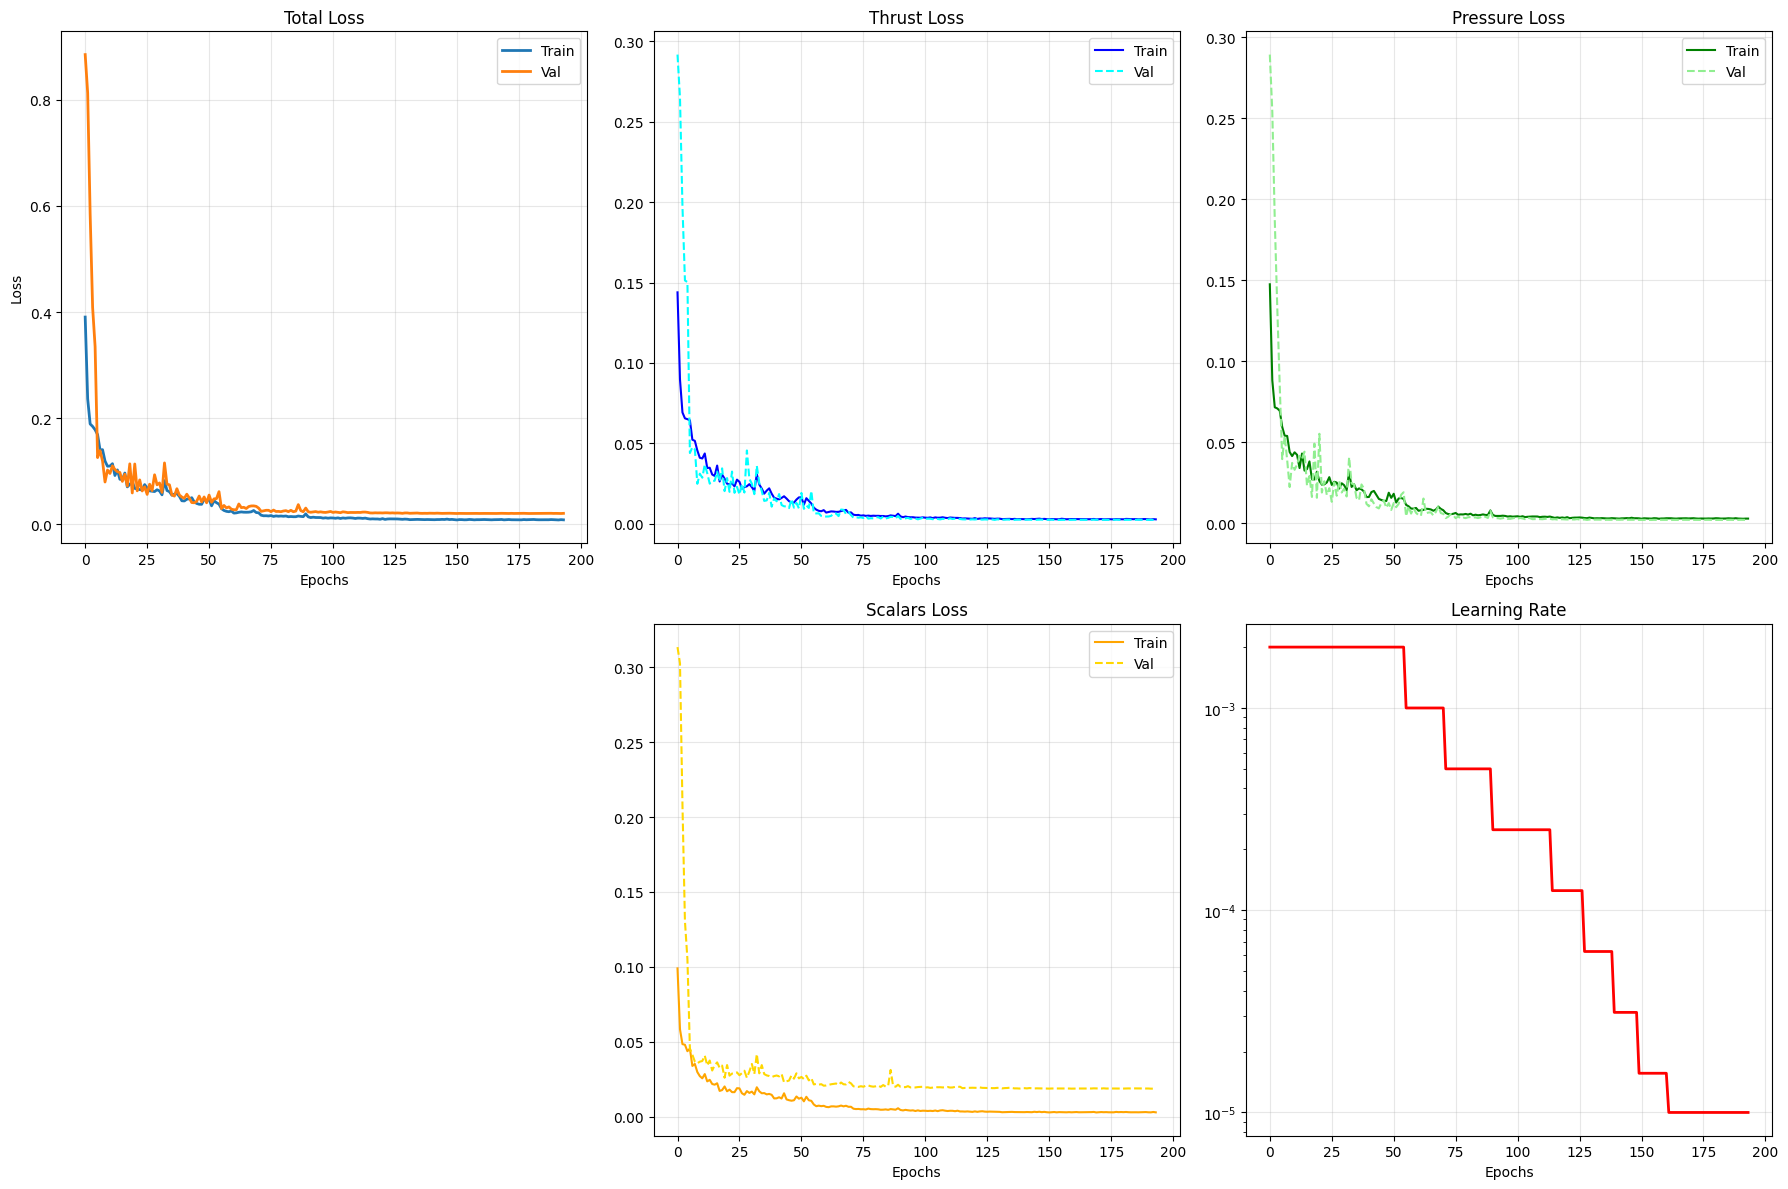

In [38]:
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plt.plot(history.history['loss'],     label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Val',   linewidth=2)
plt.title('Total Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(history.history['Thrust_loss'],     label='Train', color='blue')
plt.plot(history.history['val_Thrust_loss'], label='Val',   color='cyan', linestyle='--')
plt.title('Thrust Loss'); plt.xlabel('Epochs'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(history.history['Pressure_loss'],     label='Train', color='green')
plt.plot(history.history['val_Pressure_loss'], label='Val',   color='lightgreen', linestyle='--')
plt.title('Pressure Loss'); plt.xlabel('Epochs'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
plt.plot(history.history['Scalars_loss'],     label='Train', color='orange')
plt.plot(history.history['val_Scalars_loss'], label='Val',   color='gold', linestyle='--')
plt.title('Scalars Loss'); plt.xlabel('Epochs'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 6)
plt.plot(history.history['learning_rate'], color='red', linewidth=2)
plt.title('Learning Rate'); plt.xlabel('Epochs'); plt.yscale('log'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


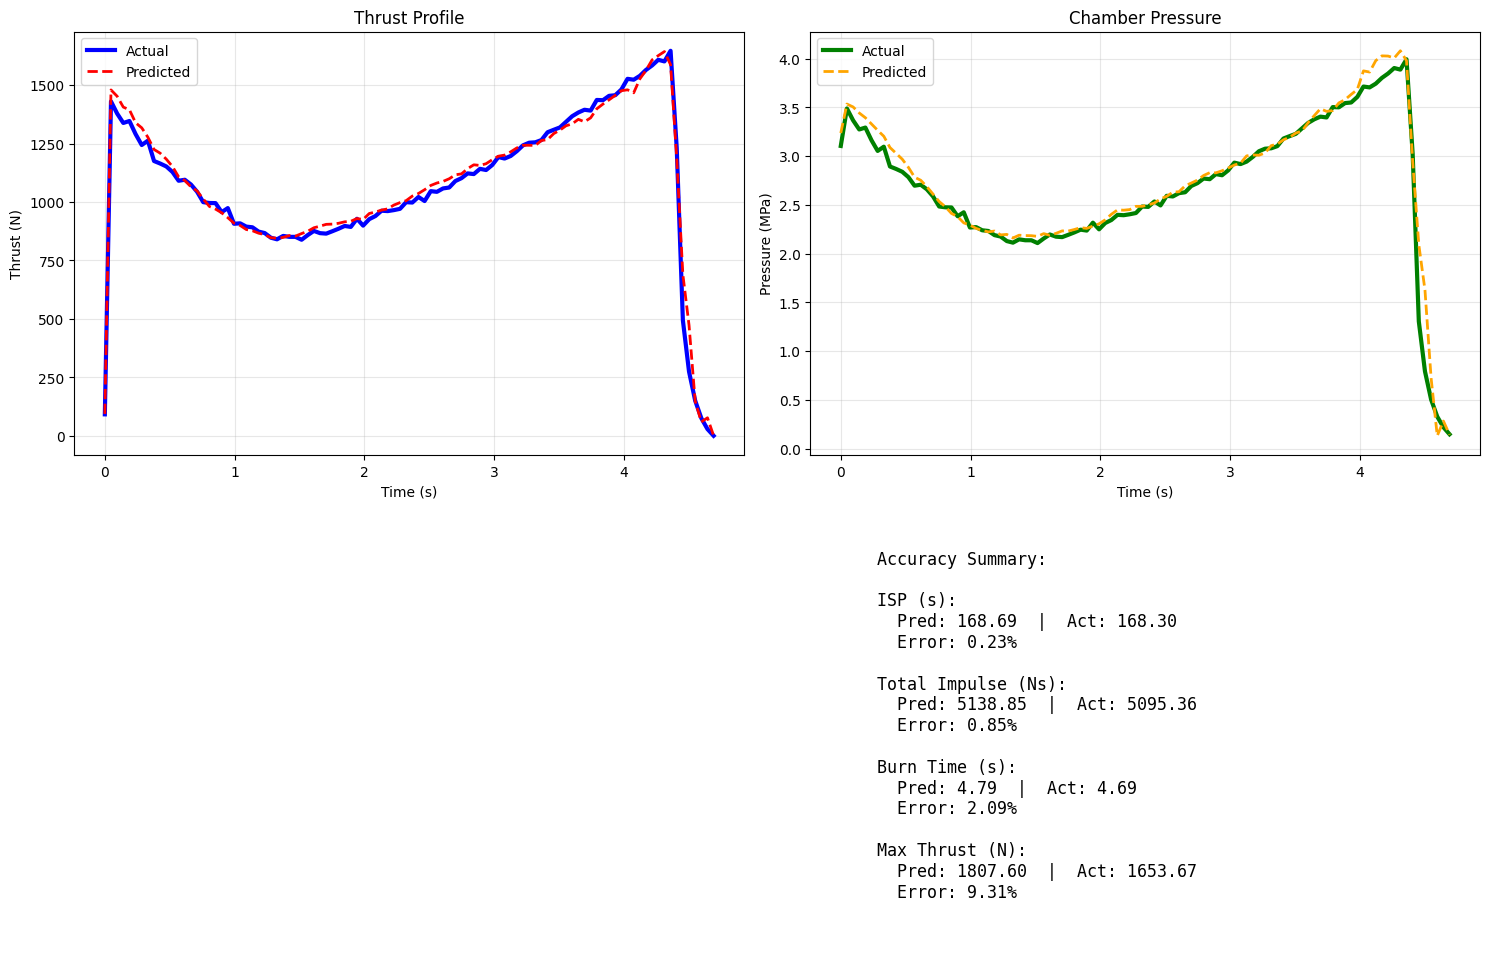

In [45]:
sample_idx = 00

preds        = model.predict(X_te_s[sample_idx:sample_idx+1])
pred_thrust  = s_yt.inverse_transform(preds[0])[0]
pred_pressure = s_yp.inverse_transform(preds[1])[0]
pred_scalars  = s_ys.inverse_transform(preds[2])[0]

act_thrust   = yt_test[sample_idx]
act_pressure = yp_test[sample_idx]
act_scalars  = ys_test[sample_idx]

time_axis = np.linspace(0, act_scalars[2], 100)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(time_axis, act_thrust,  'b-',  label='Actual',    linewidth=3)
plt.plot(time_axis, pred_thrust, 'r--', label='Predicted', linewidth=2)
plt.title('Thrust Profile'); plt.xlabel('Time (s)'); plt.ylabel('Thrust (N)')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(time_axis, act_pressure,  'g-',      label='Actual',    linewidth=3)
plt.plot(time_axis, pred_pressure, 'orange', linestyle='--', label='Predicted', linewidth=2)
plt.title('Chamber Pressure'); plt.xlabel('Time (s)'); plt.ylabel('Pressure (MPa)')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.axis('off')
labels = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)']
txt = 'Accuracy Summary:\n\n'
for i, lbl in enumerate(labels):
    err = abs(pred_scalars[i] - act_scalars[i]) / (act_scalars[i] + 1e-9) * 100
    txt += f'{lbl}:\n  Pred: {pred_scalars[i]:.2f}  |  Act: {act_scalars[i]:.2f}\n  Error: {err:.2f}%\n\n'
plt.text(0.1, 0.5, txt, fontsize=12, family='monospace', va='center')

plt.tight_layout()
plt.show()


   Star Grain Motor — AI Performance Prediction


Length (cm):              60
Outer Diameter (cm):      8
Number of Points (3/5/7/9):  3
Point Length (cm):        2
Point Base Width (cm):    1.5
Throat Diameter (cm):     1.8
Exit Diameter (cm):       2.7


/tmp/ipykernel_57/526990687.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  impulse    = np.trapz(thrust_pred, time_steps)



---------------------------------------------
  Predicted Performance
---------------------------------------------
  ISP:              173.59 s
  Total Impulse:    8309.09 Ns
  Burn Time:        4.03 s
  Max Thrust:       4128.03 N
---------------------------------------------



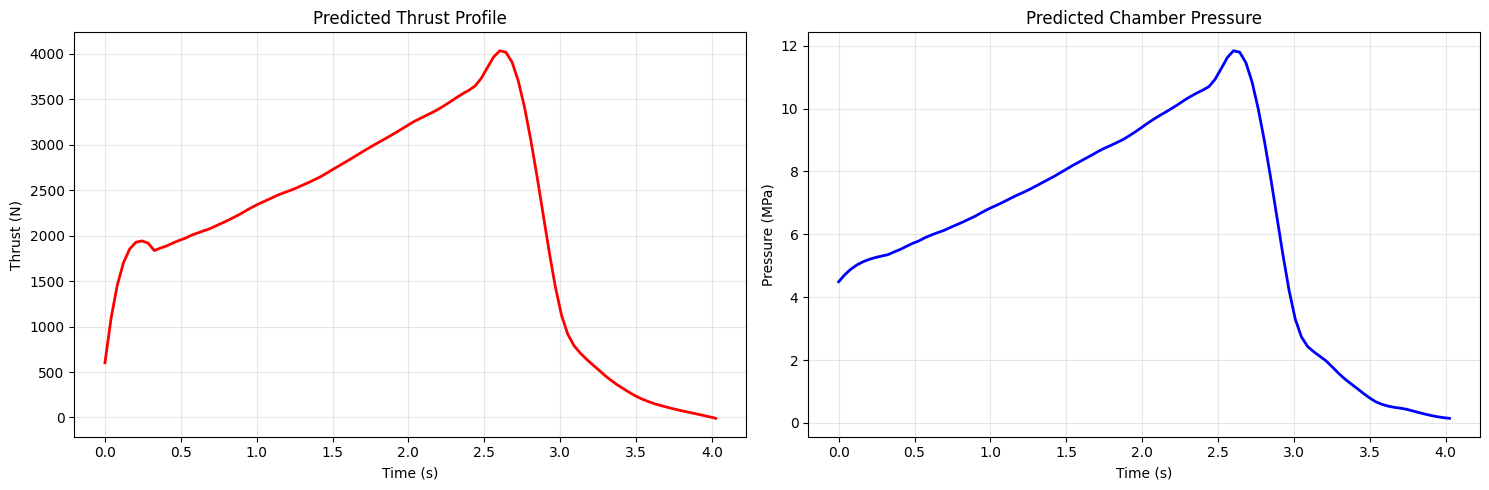

In [43]:
def predict_star_grain():
    """
    Inputs (all in cm):
      Length, Outer Diameter, Number of Points,
      Point Length, Point Base Width, Throat Diameter, Exit Diameter
    Outputs:
      Thrust profile (N) + Pressure profile (MPa)
      ISP (s), Total Impulse (Ns), Burn Time (s), Max Thrust (N)
    """
    print('\n' + '='*55)
    print('   Star Grain Motor — AI Performance Prediction')
    print('='*55)
    try:
        length     = float(input('Length (cm):             '))
        diameter   = float(input('Outer Diameter (cm):     '))
        n_points   = float(input('Number of Points (3/5/7/9): '))
        pt_length  = float(input('Point Length (cm):       '))
        pt_width   = float(input('Point Base Width (cm):   '))
        throat     = float(input('Throat Diameter (cm):    '))
        exit_d     = float(input('Exit Diameter (cm):      '))

        user_in  = np.array([[length, diameter, n_points, pt_length, pt_width, throat, exit_d]])
        user_sc  = s_X.transform(user_in)
        preds    = model.predict(user_sc, verbose=0)

        thrust_pred   = s_yt.inverse_transform(preds[0])[0]
        pressure_pred = s_yp.inverse_transform(preds[1])[0]
        scalars_pred  = s_ys.inverse_transform(preds[2])[0]

        burn_time  = scalars_pred[2]
        time_steps = np.linspace(0, burn_time, 100)
        impulse    = np.trapz(thrust_pred, time_steps)

        # Smooth for plotting
        thrust_smooth   = savgol_filter(thrust_pred,   window_length=15, polyorder=3)
        pressure_smooth = savgol_filter(pressure_pred, window_length=15, polyorder=3)

        print('\n' + '-'*45)
        print('  Predicted Performance')
        print('-'*45)
        print(f'  ISP:              {scalars_pred[0]:.2f} s')
        print(f'  Total Impulse:    {impulse:.2f} Ns')
        print(f'  Burn Time:        {burn_time:.2f} s')
        print(f'  Max Thrust:       {scalars_pred[3]:.2f} N')
        print('-'*45 + '\n')

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 2, 1)
        plt.plot(time_steps, thrust_smooth, color='red', linewidth=2)
        plt.title('Predicted Thrust Profile')
        plt.xlabel('Time (s)'); plt.ylabel('Thrust (N)')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(time_steps, pressure_smooth, color='blue', linewidth=2)
        plt.title('Predicted Chamber Pressure')
        plt.xlabel('Time (s)'); plt.ylabel('Pressure (MPa)')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except ValueError:
        print('[Error] Please enter valid numeric values.')
    except Exception as e:
        print(f'[Error] {e}')


predict_star_grain()

In [44]:
model.save('Star_model.keras')
joblib.dump(s_X,  'scaler_X.pkl')
joblib.dump(s_yt, 'scaler_thrust.pkl')
joblib.dump(s_yp, 'scaler_pressure.pkl')
joblib.dump(s_ys, 'scaler_scalars.pkl')
print('Model + Scalers saved ✓')

Model + Scalers saved ✓
